In [2]:
#importing important depences
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


In [ ]:
import mysql.connector


In [ ]:
connection = mysql.connector.connect(
    host = "localhost",
    user = "root",
    password = "ebenezerreuben0@gmail.com",
    database = "real_estate_database"
)

print("connection successful")


connection successful


In [4]:
cursor = connection.cursor()
cursor.execute("SELECT * FROM ameshousing")
result = cursor.fetchall()
for row in result:
    print(row)


(1, '0526301100', '020', 'RL', 141, 31770, 'Pave', 'NA', 'IR1', 'Lvl', 'AllPub', 'Corner', 'Gtl', 'NAmes', 'Norm', 'Norm', '1Fam', '1Story', 6, 5, 1960, 1960, 'Hip', 'CompShg', 'BrkFace', 'Plywood', 'Stone', 112, 'TA', 'TA', 'CBlock', 'TA', 'Gd', 'Gd', 'BLQ', 639, 'Unf', 0, 441, 1080, 'GasA', 'Fa', 'Y', 'SBrkr', 1656, 0, 0, 1656, 1, 0, 1, 0, 3, 1, 'TA', 7, 'Typ', 2, 'Gd', 'Attchd', 1960, 'Fin', 2, 528, 'TA', 'TA', 'P', 210, 62, 0, 0, 0, 0, 'NA', 'NA', 'NA', 0, 5, 2010, 'WD ', 'Normal', 215000)
(2, '0526350040', '020', 'RH', 80, 11622, 'Pave', 'NA', 'Reg', 'Lvl', 'AllPub', 'Inside', 'Gtl', 'NAmes', 'Feedr', 'Norm', '1Fam', '1Story', 5, 6, 1961, 1961, 'Gable', 'CompShg', 'VinylSd', 'VinylSd', 'None', 0, 'TA', 'TA', 'CBlock', 'TA', 'TA', 'No', 'Rec', 468, 'LwQ', 144, 270, 882, 'GasA', 'TA', 'Y', 'SBrkr', 896, 0, 0, 896, 0, 0, 1, 0, 2, 1, 'TA', 5, 'Typ', 0, 'NA', 'Attchd', 1961, 'Unf', 1, 730, 'TA', 'TA', 'Y', 140, 0, 0, 0, 120, 0, 'NA', 'MnPrv', 'NA', 0, 6, 2010, 'WD ', 'Normal', 105000)


In [7]:
query = "SELECT * FROM ameshousing"
data = pd.read_sql(query, connection)

C:\Users\user\AppData\Local\Temp\ipykernel_12472\2494246351.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data = pd.read_sql(query, connection)


In [6]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,0526301100,020,RL,141,31770,Pave,NA,IR1,Lvl,...,0,NA,NA,NA,0,5,2010,WD,Normal,215000
1,2,0526350040,020,RH,80,11622,Pave,NA,Reg,Lvl,...,0,NA,MnPrv,NA,0,6,2010,WD,Normal,105000
2,3,0526351010,020,RL,81,14267,Pave,NA,IR1,Lvl,...,0,NA,NA,Gar2,12500,6,2010,WD,Normal,172000
3,4,0526353030,020,RL,93,11160,Pave,NA,Reg,Lvl,...,0,NA,NA,NA,0,4,2010,WD,Normal,244000
4,5,0527105010,060,RL,74,13830,Pave,NA,IR1,Lvl,...,0,NA,MnPrv,NA,0,3,2010,WD,Normal,189900



**(1.) PROBLEM DEFINITION :**

 This project focuses on developing a machine learning model to estimate 
 
 
 house prices using features such as square footage,
  
  
  number of bedrooms, and location, drawing from a comprehensive real estate dataset

  and also to Derive new variables like total living area or age of property renovations. 

**(2.) LOADING THE DATASET**

In [8]:
data.shape

(2274, 82)

**3. DATA CLEANING**

In [4]:
# checking for the columns
data.columns.unique()

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [5]:
# selecting the important features
select_colunms = ["Gr Liv Area", # Above ground living area
                "Bedroom AbvGr", # Numbers of the bedrooms above the grade
                "Neighborhood", # Location
                "Year Built",
                "Year Remod/Add", #Year remodeled
                "Yr Sold",
                "Total Bsmt SF", #basement size
                "SalePrice" ]# targert
df = data[select_colunms]
df.head()

,Gr Liv Area,Bedroom AbvGr,Neighborhood,Year Built,Year Remod/Add,Yr Sold,Total Bsmt SF,SalePrice
0,1656,3,NAmes,1960,1960,2010,1080.0,215000
1,896,2,NAmes,1961,1961,2010,882.0,105000
2,1329,3,NAmes,1958,1958,2010,1329.0,172000
3,2110,3,NAmes,1968,1968,2010,2110.0,244000
4,1629,3,Gilbert,1997,1998,2010,928.0,189900


In [6]:
df["Neighborhood"].value_counts()

Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    194
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
SawyerW    125
Mitchel    114
BrkSide    108
Crawfor    103
IDOTRR      93
Timber      72
NoRidge     71
StoneBr     51
SWISU       48
ClearCr     44
MeadowV     37
BrDale      30
Blmngtn     28
Veenker     24
NPkVill     23
Blueste     10
Greens       8
GrnHill      2
Landmrk      1
Name: count, dtype: int64

In [7]:
#Removing inconsistences
df["Neighborhood"] = df["Neighborhood"].replace("NAmes","NWAmes")
df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_4532\1301725665.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Neighborhood"] = df["Neighborhood"].replace("NAmes","NWAmes")


,Gr Liv Area,Bedroom AbvGr,Neighborhood,Year Built,Year Remod/Add,Yr Sold,Total Bsmt SF,SalePrice
0,1656,3,NWAmes,1960,1960,2010,1080.0,215000
1,896,2,NWAmes,1961,1961,2010,882.0,105000
2,1329,3,NWAmes,1958,1958,2010,1329.0,172000
3,2110,3,NWAmes,1968,1968,2010,2110.0,244000
4,1629,3,Gilbert,1997,1998,2010,928.0,189900


In [8]:
# Checking for missing values
df.isnull().sum()

Gr Liv Area       0
Bedroom AbvGr     0
Neighborhood      0
Year Built        0
Year Remod/Add    0
Yr Sold           0
Total Bsmt SF     1
SalePrice         0
dtype: int64

There is one missing value

In [9]:
df['Total Bsmt SF'].fillna(df['Total Bsmt SF'].median(), inplace = True)

C:\Users\user\AppData\Local\Temp\ipykernel_4532\4203495685.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total Bsmt SF'].fillna(df['Total Bsmt SF'].median(), inplace = True)
C:\Users\user\AppData\Local\Temp\ipykernel_4532\4203495685.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Total Bsmt SF'].fillna(df['Total Bsmt SF'].med

In [10]:
df.isnull().sum()

Gr Liv Area       0
Bedroom AbvGr     0
Neighborhood      0
Year Built        0
Year Remod/Add    0
Yr Sold           0
Total Bsmt SF     0
SalePrice         0
dtype: int64

In [11]:
# checking for duplicate
df.duplicated().sum()


np.int64(7)

In [12]:
# Dropping duplicates
df = df.drop_duplicates()

In [13]:
# Handling outliers
df['SalePrice_log'] = np.log1p(df['SalePrice'])

In [14]:
target_column = ['SalePrice', 'SalePrice_log']
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
numerical_columns = df.select_dtypes(include=['int64', 'float']).columns.tolist()
                     
#Removing the target column from the numerical columns
numerical_columns= [col for col in numerical_columns if col not in target_column]
print(numerical_columns)
print(categorical_columns)




['Gr Liv Area', 'Bedroom AbvGr', 'Year Built', 'Year Remod/Add', 'Yr Sold', 'Total Bsmt SF']
['Neighborhood']


In [15]:
ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded_category = ohe.fit_transform(df[categorical_columns])

# coverting it to a dataframe
encodd_df = pd.DataFrame(encoded_category, columns=ohe.get_feature_names_out(categorical_columns))
print(encodd_df)


      Neighborhood_Blueste  Neighborhood_BrDale  Neighborhood_BrkSide  \
0                      0.0                  0.0                   0.0   
1                      0.0                  0.0                   0.0   
2                      0.0                  0.0                   0.0   
3                      0.0                  0.0                   0.0   
4                      0.0                  0.0                   0.0   
...                    ...                  ...                   ...   
2918                   0.0                  0.0                   0.0   
2919                   0.0                  0.0                   0.0   
2920                   0.0                  0.0                   0.0   
2921                   0.0                  0.0                   0.0   
2922                   0.0                  0.0                   0.0   

      Neighborhood_ClearCr  Neighborhood_CollgCr  Neighborhood_Crawfor  \
0                      0.0                   0.0 

In [16]:
scaler = StandardScaler()
sacled_num =scaler.fit_transform(df[numerical_columns])
scaled_df = pd.DataFrame(sacled_num, columns=numerical_columns)
print(scaled_df)

      Gr Liv Area  Bedroom AbvGr  Year Built  Year Remod/Add   Yr Sold  \
0        0.310923       0.179000   -0.373896       -1.162445  1.678739   
1       -1.194539      -1.034959   -0.340838       -1.114512  1.678739   
2       -0.336822       0.179000   -0.440011       -1.258313  1.678739   
3        1.210238       0.179000   -0.109432       -0.778976  1.678739   
4        0.257439       0.179000    0.849250        0.659035  1.678739   
...           ...            ...         ...             ...       ...   
2918    -0.982585       0.179000    0.419496       -0.012037 -1.358212   
2919    -1.182653      -1.034959    0.386438       -0.059970 -1.358212   
2920    -1.047954       0.179000    0.683960        0.371433 -1.358212   
2921    -0.217970      -1.034959    0.088916       -0.443440 -1.358212   
2922     0.992342       0.179000    0.717018        0.467300 -1.358212   

      Total Bsmt SF  
0          0.063335  
1         -0.386700  
2          0.629288  
3          2.404426  
4

In [17]:
# concatenating it



scaled_df = scaled_df.reset_index(drop=True)
encodd_df = encodd_df.reset_index(drop=True)
target_df = df[target_column].reset_index(drop=True)

concat_df = pd.concat([scaled_df, encodd_df, target_df], axis=1)
concat_df.head()

,Gr Liv Area,Bedroom AbvGr,Year Built,Year Remod/Add,Yr Sold,Total Bsmt SF,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,...,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,SalePrice,SalePrice_log
0,0.310923,0.179000,-0.373896,-1.162445,1.678739,0.063335,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,215000,12.278398
1,-1.194539,-1.034959,-0.340838,-1.114512,1.678739,-0.386700,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,105000,11.561725
2,-0.336822,0.179000,-0.440011,-1.258313,1.678739,0.629288,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,172000,12.055256
3,1.210238,0.179000,-0.109432,-0.778976,1.678739,2.404426,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,244000,12.404928
4,0.257439,0.179000,0.849250,0.659035,1.678739,-0.282146,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,189900,12.154258


In [18]:

clean_df = concat_df.drop(columns=['SalePrice'])
clean_df.head()

,Gr Liv Area,Bedroom AbvGr,Year Built,Year Remod/Add,Yr Sold,Total Bsmt SF,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,...,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,SalePrice_log
0,0.310923,0.179000,-0.373896,-1.162445,1.678739,0.063335,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.278398
1,-1.194539,-1.034959,-0.340838,-1.114512,1.678739,-0.386700,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.561725
2,-0.336822,0.179000,-0.440011,-1.258313,1.678739,0.629288,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.055256
3,1.210238,0.179000,-0.109432,-0.778976,1.678739,2.404426,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.404928
4,0.257439,0.179000,0.849250,0.659035,1.678739,-0.282146,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.154258


**3. EDA**

In [19]:
#checking for the descriptive statistics for numerical column
df.describe()



,Gr Liv Area,Bedroom AbvGr,Year Built,Year Remod/Add,Yr Sold,Total Bsmt SF,SalePrice,SalePrice_log
count,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000
mean,1499.037290,2.852549,1971.310298,1984.251112,2007.788915,1052.134793,180793.054396,12.020941
std,504.915043,0.823892,30.255062,20.865723,1.317336,440.041121,79915.178796,0.407587
min,334.000000,0.000000,1872.000000,1950.000000,2006.000000,0.000000,12789.000000,9.456419
25%,1125.500000,2.000000,1954.000000,1965.000000,2007.000000,793.000000,129500.000000,11.771444
50%,1442.000000,3.000000,1973.000000,1993.000000,2008.000000,990.000000,160000.000000,11.982935
75%,1742.500000,3.000000,2001.000000,2004.000000,2009.000000,1302.000000,213500.000000,12.271397
max,5642.000000,8.000000,2010.000000,2010.000000,2010.000000,6110.000000,755000.000000,13.534474


**1. Checking for the Correlation via Heat map**

                Gr Liv Area  Bedroom AbvGr  Year Built  Year Remod/Add  \
Gr Liv Area        1.000000       0.514127    0.240873        0.316341   
Bedroom AbvGr      0.514127       1.000000   -0.057461       -0.023287   
Year Built         0.240873      -0.057461    1.000000        0.611598   
Year Remod/Add     0.316341      -0.023287    0.611598        1.000000   
Yr Sold           -0.027937      -0.021119   -0.013855        0.032483   
Total Bsmt SF      0.445719       0.052100    0.408246        0.296785   
SalePrice          0.706794       0.141882    0.558543        0.532723   
SalePrice_log      0.695879       0.178532    0.615611        0.585789   

                 Yr Sold  Total Bsmt SF  SalePrice  SalePrice_log  
Gr Liv Area    -0.027937       0.445719   0.706794       0.695879  
Bedroom AbvGr  -0.021119       0.052100   0.141882       0.178532  
Year Built     -0.013855       0.408246   0.558543       0.615611  
Year Remod/Add  0.032483       0.296785   0.532723       0.58

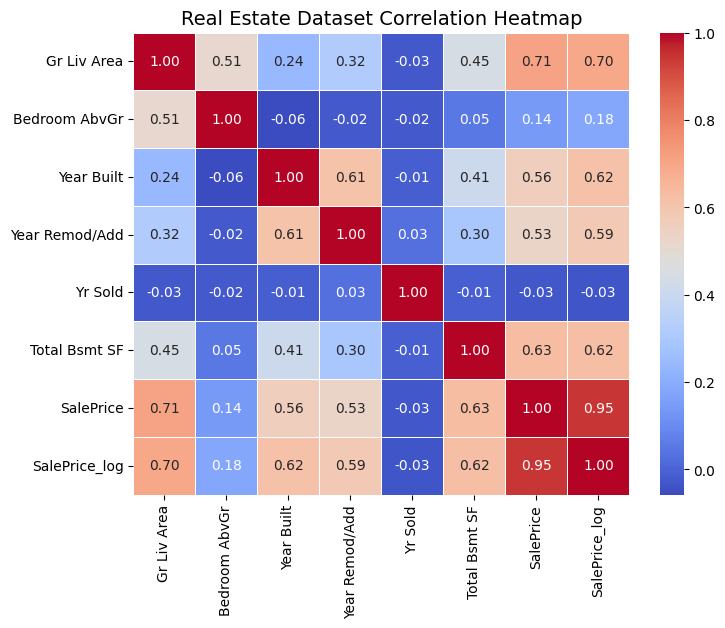

In [20]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt= '.2f', linewidths=0.5)
plt.title("Real Estate Dataset Correlation Heatmap", fontsize = 14)
plt.show()

**Checking for outliers Using Boxplot**

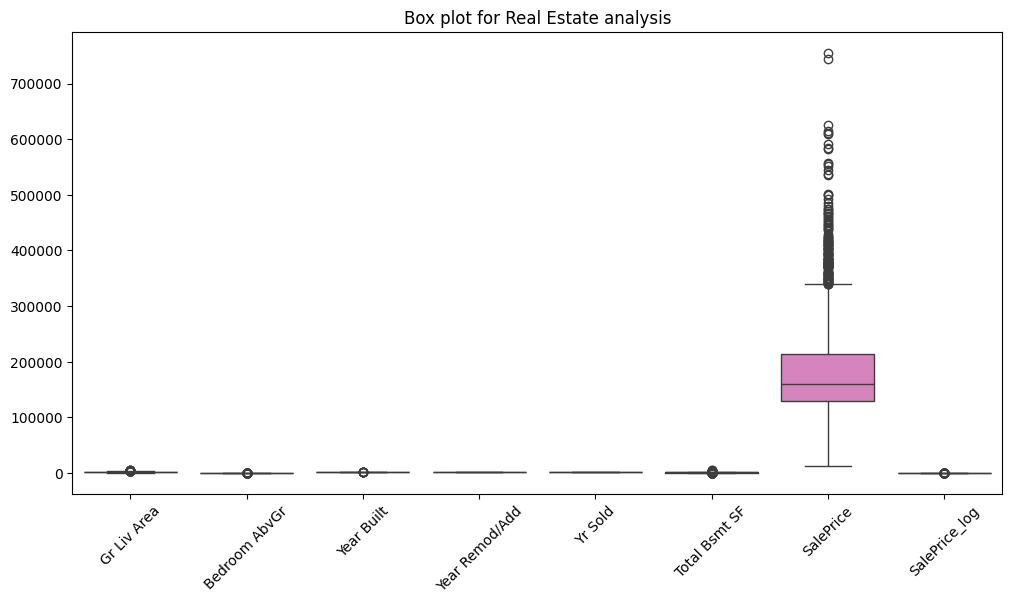

In [21]:
numerical_columns=df.select_dtypes(include=['int64', 'float']).columns
plt.figure(figsize=(12,6))
sns.boxplot(data= df[numerical_columns])
plt.title('Box plot for Real Estate analysis')
plt.xticks(rotation=45)
plt.show()

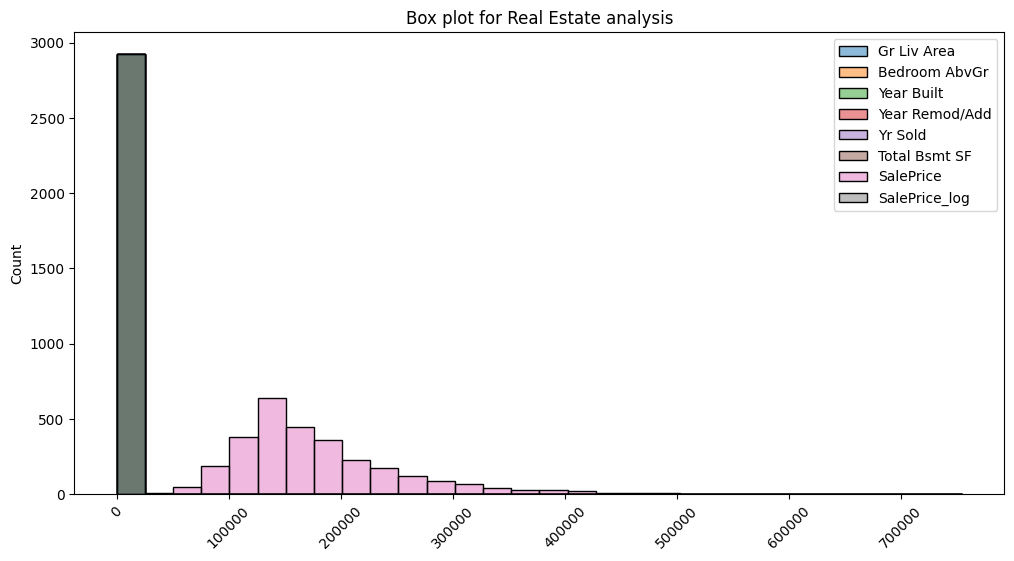

In [22]:
numerical_columns=df.select_dtypes(include=['int64', 'float']).columns
plt.figure(figsize=(12,6))
sns.histplot(data= df[numerical_columns], bins=30, color= 'green')
plt.title('Box plot for Real Estate analysis')
plt.xticks(rotation=45)
plt.show()

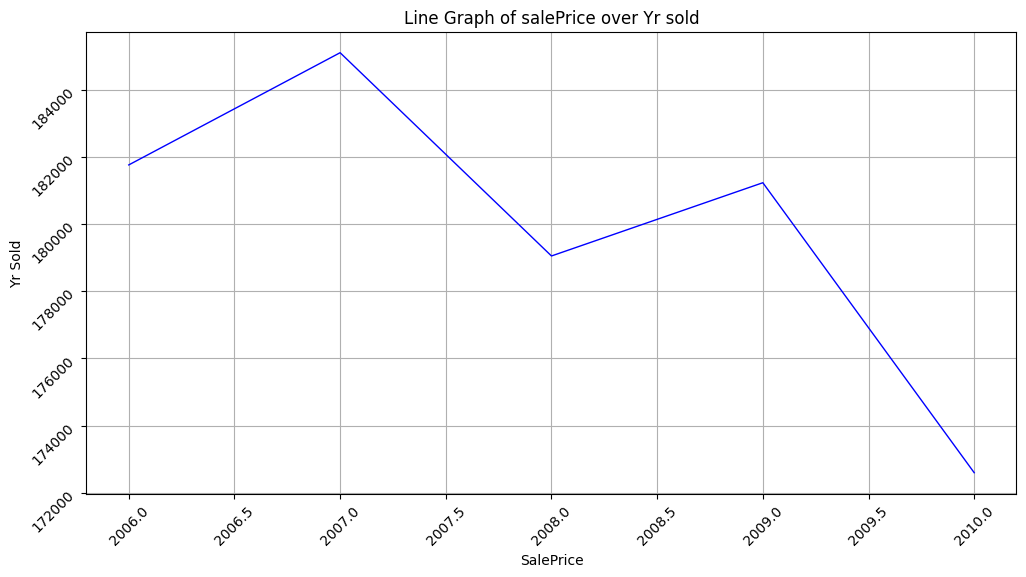

In [23]:
plt.figure(figsize=(12,6))
sns.lineplot(x='Yr Sold', y='SalePrice', data=df, color = 'blue', errorbar=None, linewidth=1)
plt.title('Line Graph of salePrice over Yr sold')
plt.xlabel('SalePrice')
plt.ylabel('Yr Sold')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.grid(True)
plt.show()

**MODEL TRAINING**

In [24]:
#Spliting my dataset
x = clean_df.drop(columns=['SalePrice_log'])
y = clean_df['SalePrice_log']

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)


In [26]:
df.shape

(2923, 9)

In [27]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)


(2338, 32) (2338,)
(585, 32) (585,)


In [28]:
models = {
    'Linear Regression': {'model' :LinearRegression(),
                          'param' : {# LinearRegression doesn't have many hyperparameters to tune
                                   'copy_X' : [True,False], 
                                    'fit_intercept' : [True, False], 
                                    'n_jobs': [-1, 1, 2], 
                                    'positive': [True, False], 
                                    'tol': [1e-4, 1e-3, 1e-5]
                                    } 
                        },
    'RandomForest': {'model':RandomForestRegressor(random_state=42),
                       'param': {'n_estimators': [50, 100],
                                  'max_depth': [None, 10, 20],
                                  'min_samples_split': [2, 5]}
                      },
    'XGBoost': {'model':XGBRegressor(objective='reg:squarederror', random_state=42),
              'param' : {'n_estimators' : [50, 100],
                         'max_depth': [3, 5, 7],
                         'learning_rate': [0.01, 0.1, 0.2]
                        }
                }}


In [29]:
for model_name, model_param in models.items():
    grid = GridSearchCV(model_param['model'], model_param['param'], cv=5)
    grid.fit(x_train,y_train)
    print(f'{model_name} best param:{grid.best_params_}')

Linear Regression best param:{'copy_X': True, 'fit_intercept': True, 'n_jobs': -1, 'positive': False, 'tol': 0.0001}
RandomForest best param:{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
XGBoost best param:{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50}


In [75]:


results = {}

for model_name, model_param in models.items():
    grid = GridSearchCV(model_param['model'], model_param['param'], cv=5)
    grid.fit(x_train, y_train)
    
    best_model = grid.best_estimator_
    
    # Predict on test data
    y_pred = best_model.predict(x_test)

    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[model_name] = {
        'Best Parameters': grid.best_params_,
        'MSE': mse,
        'R2': r2
    }

# Print results
for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    print(f"  Best Parameters: {metrics['Best Parameters']}")
    print(f"  MSE: {metrics['MSE']:.2f}")
    print(f"  R2 Score: {metrics['R2']:.2f}\n")

Model: Linear Regression
  Best Parameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': -1, 'positive': False, 'tol': 0.0001}
  MSE: 0.0258
  R2 Score: 0.8477

Model: RandomForest
  Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
  MSE: 0.0214
  R2 Score: 0.8736

Model: XGBoost
  Best Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50}
  MSE: 0.0212
  R2 Score: 0.8748



In [ ]:
new_data= input(1656,3,'NWAmes',1960,1960,2010,1080.0)
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
numerical_columns = df.select_dtypes(include=['int64', 'float']).columns.tolist()